/tmp/ipykernel_3651/3502023482.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", TOP_N)


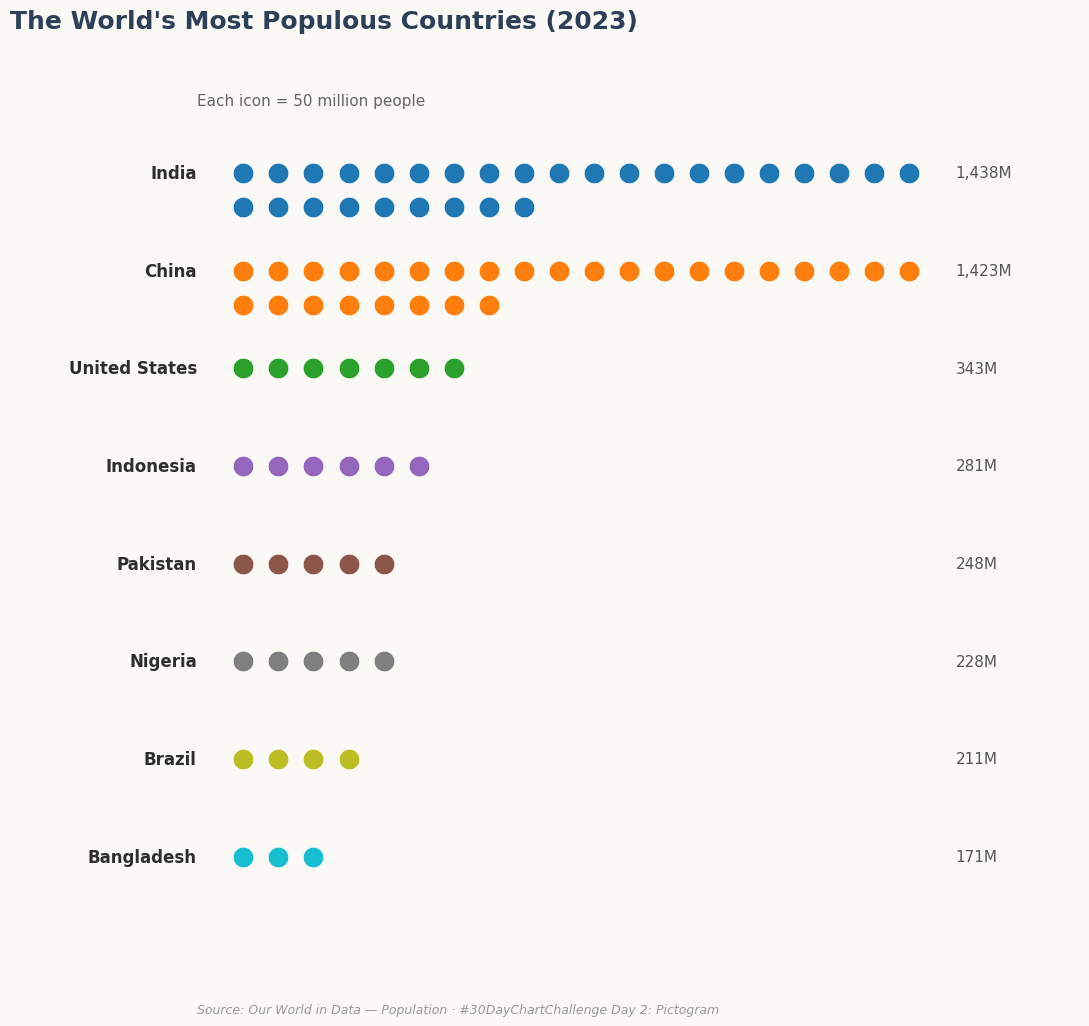

In [1]:
"""
#30DayChartChallenge — Day 2: Pictogram
"The world's most populous countries, one icon per X million people"

Data source (loaded live, no hardcoded values):
Our World in Data — Population
https://ourworldindata.org/population-growth

Each filled circle ("icon") represents a fixed number of people
(auto-calculated below from the data itself, so nothing is hardcoded).
"""

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. CONFIG
# ---------------------------------------------------------------------------
TOP_N = 8          # how many countries to show
ICONS_PER_ROW = 20  # wrap icons onto a new row after this many

DATA_URL = "https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=false"

# ---------------------------------------------------------------------------
# 2. LOAD DATA DIRECTLY FROM SOURCE
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_URL, storage_options={"User-Agent": "Mozilla/5.0"})

# Keep only real countries: OWID's regional/income-group aggregates use
# non-ISO codes like "OWID_ASI" or "UN_AFR" (len != 3), or have no code at all.
countries = df[df["Code"].notna() & (df["Code"].str.len() == 3)].copy()

# Use the most recent year available
latest_year = int(countries["Year"].max())
latest = countries[countries["Year"] == latest_year]

# Top N most populous countries this year
top = latest.sort_values("Population", ascending=False).head(TOP_N).reset_index(drop=True)

# ---------------------------------------------------------------------------
# 3. PICK A "NICE" VALUE PER ICON, DERIVED FROM THE DATA
# ---------------------------------------------------------------------------
max_pop = top["Population"].max()
raw_unit = max_pop / (ICONS_PER_ROW * 2)  # aim for ~2 rows for the biggest country
magnitude = 10 ** math.floor(math.log10(raw_unit))
for mult in (1, 2, 5, 10):
    value_per_icon = mult * magnitude
    if raw_unit <= value_per_icon:
        break

top["icons"] = (top["Population"] / value_per_icon).round().astype(int).clip(lower=1)

# ---------------------------------------------------------------------------
# 4. PLOT — pictogram (grid of circles per country)
# ---------------------------------------------------------------------------
fig_height = 1.1 * TOP_N + 1.5
fig, ax = plt.subplots(figsize=(11, fig_height), facecolor="#FAF9F6")
ax.set_facecolor("#FAF9F6")

palette = plt.cm.get_cmap("tab10", TOP_N)
icon_size = 220

for i, row in top.iterrows():
    y = TOP_N - i  # top country at the top
    n_icons = row["icons"]
    rows_needed = math.ceil(n_icons / ICONS_PER_ROW)
    color = palette(i)

    for j in range(n_icons):
        col = j % ICONS_PER_ROW
        sub_row = j // ICONS_PER_ROW
        x = col * 0.9
        yy = y - sub_row * 0.35
        ax.scatter(x, yy, s=icon_size, color=color, edgecolor="white", linewidth=0.5, zorder=3)

    # Country label to the left
    ax.text(-1.2, y, row["Entity"], ha="right", va="center", fontsize=12, fontweight="bold", color="#2E2E2E")
    # Population figure to the right of the icons
    label_x = ICONS_PER_ROW * 0.9 + 0.3
    ax.text(
        label_x, y,
        f"{row['Population'] / 1e6:,.0f}M",
        ha="left", va="center", fontsize=11, color="#555555",
    )

ax.set_xlim(-6, ICONS_PER_ROW * 0.9 + 3.5)
ax.set_ylim(0, TOP_N + 1.2)
ax.axis("off")

ax.set_title(
    f"The World's Most Populous Countries ({latest_year})",
    fontsize=18, fontweight="bold", color="#2E4057", pad=20, loc="left",
)
ax.text(
    -1.2, TOP_N + 0.7,
    f"Each icon = {value_per_icon / 1e6:,.0f} million people",
    fontsize=11, color="#666666", ha="left",
)
ax.text(
    -1.2, -0.6,
    "Source: Our World in Data — Population · #30DayChartChallenge Day 2: Pictogram",
    fontsize=9, color="#999999", ha="left", style="italic",
)

plt.tight_layout()
plt.savefig("day2_pictogram.png", dpi=200, facecolor="#FAF9F6", bbox_inches="tight")
plt.show()